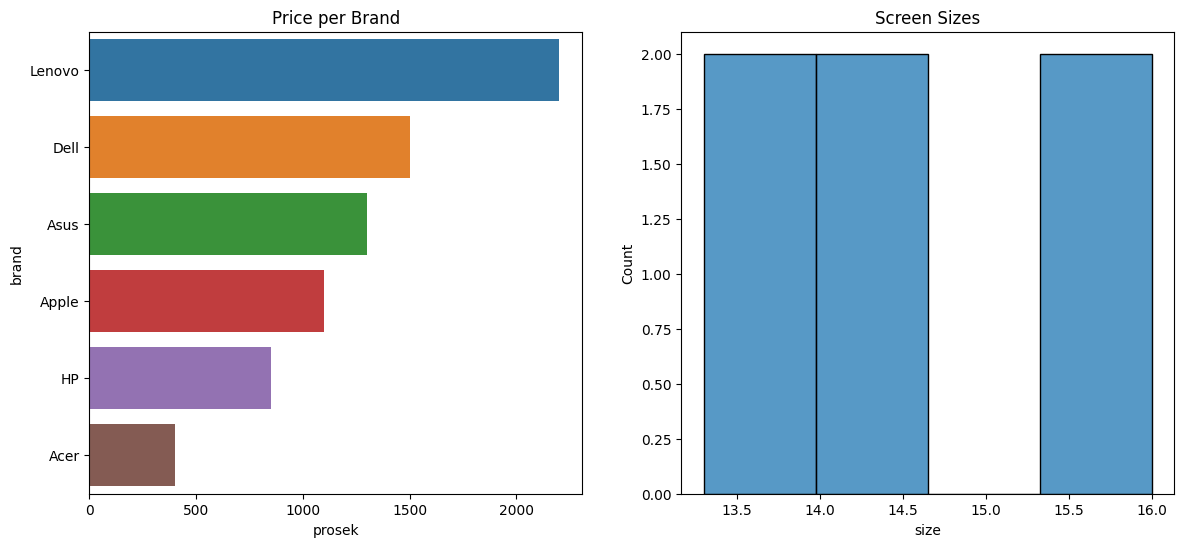

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


data = {
    'Laptop_Model': ['MacBook Air', 'Dell XPS', 'HP Pavilion', 'Dell XPS', 'Lenovo Legion', 'Asus Zenbook', 'MacBook Air', np.nan, 'Acer Swift'],
    'Specs': ['8GB RAM | 256GB SSD', '16GB RAM | 512GB SSD', '8GB RAM | 256GB SSD', '16GB RAM | 512GB SSD', '32GB RAM | 1TB SSD', '16GB RAM | 512GB SSD', '8GB RAM | 256GB SSD', '8GB RAM | 128GB SSD', '4GB RAM | 128GB HDD'],
    'Price_String': ['€1100', '€1500', '€850', '€1500', '€2200', '€1300', '€1100', '€600', '€400'],
    'Screen_Size': [13.3, 13.4, 15.6, 13.4, 16.0, 14.0, 13.3, 11.6, 14.0],
    'Brand': ['Apple', 'Dell', 'HP', 'Dell', 'Lenovo', 'Asus', 'Apple', 'Unknown', 'Acer']
}

df = pd.DataFrame(data)

# Data Manipulation
# 1. Duplicates

df.drop_duplicates(keep="first", inplace=True, ignore_index=True)

# 2. NaN

df.dropna(axis=0, inplace=True, ignore_index=True)

# 3. Extract and Convert

df.columns = ["model", "specs", "price", "size", "brand"]
df["price"] = df["price"].str.replace("€", "").str.strip().astype(int)

def parse_text(text):
    parts = str(text).split("|")

    try:
        return parts[0]
    except (ValueError, IndexError):
        return np.nan
    
df["ram"] = df["specs"].apply(parse_text).str.strip().str.replace("GB RAM", "").astype(int)
df.drop("specs", axis=1, inplace=True)

# 4. Filter

df_high_end = df[df["ram"] > 8]

# 5. Group

df_grouped = df.groupby("brand").agg(
    prosek = ("price", "mean")
).reset_index().sort_values(by="prosek", ascending=False)

# 6. Visualisation

fig, axs = plt.subplots(1, 2, figsize=(14,6))

sns.barplot(df_grouped, x = "prosek", y = "brand", hue="brand", ax = axs[0])
axs[0].set_title("Price per Brand")

sns.histplot(df, x = "size", ax = axs[1])
axs[1].set_title("Screen Sizes")

plt.show()

In [54]:
fig = px.scatter(df, 
                 x = "ram", 
                 y = "price", 
                 color="brand", 
                 color_discrete_map=dict(Apple = "#FF0000", Dell = "#FF8C00", HP = "#FFFF00", Lenovo = "#48FF00", Asus = "#00F2FF", Acer = "#0000FF"),
                 hover_name="brand", 
                 template="plotly_dark")

fig.update_traces(hovertemplate="<b>Brand:</b> %{hovertext}<br><b>Ram(GB):</b> %{x}<br><b>Price:</b> %{y}<br><extra></extra>")

fig.update_xaxes(title="Ram (GB)", title_font=dict(size=18, color="#00FF00"), dtick=4)
fig.update_yaxes(title="Price (USD)", title_font=dict(size=18, color="#00FF00"))

fig.update_layout(title=dict(text="Correlation between ram size and price", font=dict(size=20, color="#00FF00"), xanchor="center", x=0.5, y=0.95),
                  legend=dict(orientation="h", xanchor="center", yanchor="bottom", x=0.5, y=1),
                  margin=dict(t=80))

fig.show()